In [1]:
# Load the progress dataset and keep only episodes with completed sheet0 progress review.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROGRESS_CSV = Path('/home/mark/dabtroll/data/logs/episode_progress_rows.csv')
if not PROGRESS_CSV.exists():
    raise FileNotFoundError(f'Missing progress dataset: {PROGRESS_CSV}')

progress_df = pd.read_csv(PROGRESS_CSV)
PROGRESS_REVIEWED_DF = progress_df[progress_df['progress_reviewed'].fillna(0).astype(int).eq(1)].copy()

if PROGRESS_REVIEWED_DF.empty:
    raise ValueError('No reviewed episodes found (progress_reviewed == 1).')

def _episode_max_second(row, hard_cap=25):
    """Return the valid second ceiling for this episode based on video_length_seconds."""
    v = pd.to_numeric(row.get('video_length_seconds', np.nan), errors='coerce')
    if pd.isna(v):
        return hard_cap
    return int(np.clip(int(v), 1, hard_cap))

seconds = list(range(1, 26))
model_map = {
    'reviewer': 'Reviewer',
    'qwen3': 'Qwen3',
    'qwen3_5': 'Qwen3.5',
    'qwen3_5_mod1': 'Qwen3.5 mod1',
}

long_rows = []
validity_rows = []
for _, row in PROGRESS_REVIEWED_DF.iterrows():
    ep_idx = pd.to_numeric(row.get('episode_index', np.nan), errors='coerce')
    ep_key = f"{row.get('run_tag', '')}:ep_{int(ep_idx)}" if pd.notna(ep_idx) else f"{row.get('run_tag', '')}:ep_nan"
    max_valid_second = _episode_max_second(row, hard_cap=max(seconds))

    for suffix, label in model_map.items():
        valid_non_nan = 0
        discarded_non_nan = 0
        for sec in seconds:
            col = f'{sec}s_{suffix}'
            if col not in PROGRESS_REVIEWED_DF.columns:
                continue
            val = pd.to_numeric(row.get(col, np.nan), errors='coerce')
            if sec <= max_valid_second and pd.notna(val):
                valid_non_nan += 1
            if sec > max_valid_second and pd.notna(val):
                discarded_non_nan += 1

            long_rows.append({
                'episode_key': ep_key,
                'scenario_id': row.get('scenario_id', ''),
                'run_tag': row.get('run_tag', ''),
                'episode_index': ep_idx,
                'video_length_seconds': pd.to_numeric(row.get('video_length_seconds', np.nan), errors='coerce'),
                'max_valid_second': max_valid_second,
                'second': sec,
                'source': label,
                'progress': val,
                'valid_for_episode': sec <= max_valid_second,
            })

        validity_rows.append({
            'episode_key': ep_key,
            'scenario_id': row.get('scenario_id', ''),
            'run_tag': row.get('run_tag', ''),
            'episode_index': ep_idx,
            'source': label,
            'video_length_seconds': pd.to_numeric(row.get('video_length_seconds', np.nan), errors='coerce'),
            'max_valid_second': max_valid_second,
            'valid_non_nan_points': valid_non_nan,
            'discarded_non_nan_points': discarded_non_nan,
        })

PROGRESS_LONG_DF_ALL = pd.DataFrame(long_rows)
PROGRESS_LONG_DF = PROGRESS_LONG_DF_ALL[PROGRESS_LONG_DF_ALL['valid_for_episode']].dropna(subset=['progress']).copy()
EPISODE_SOURCE_VALIDITY_DF = pd.DataFrame(validity_rows)

display(Markdown('### Reviewed Progress Dataset Overview (video-length constrained)'))
print('rows (episodes):', len(PROGRESS_REVIEWED_DF))
print('unique reviewed episodes:', PROGRESS_REVIEWED_DF['episode_dir'].nunique())
print('long rows in valid window (non-NaN):', len(PROGRESS_LONG_DF))
print('long rows beyond valid window (all values):', int((~PROGRESS_LONG_DF_ALL['valid_for_episode']).sum()))

if not EPISODE_SOURCE_VALIDITY_DF.empty:
    validity_summary = (
        EPISODE_SOURCE_VALIDITY_DF.groupby('source')[['valid_non_nan_points', 'discarded_non_nan_points']]
        .sum()
        .reset_index()
    )
    validity_summary['pct_discarded_of_non_nan'] = (
        validity_summary['discarded_non_nan_points']
        / (validity_summary['valid_non_nan_points'] + validity_summary['discarded_non_nan_points']).replace(0, np.nan)
    ).fillna(0.0)
    display(Markdown('### Kept vs Discarded Non-NaN Progress Points by Source'))
    display(validity_summary)

display(PROGRESS_REVIEWED_DF[['scenario_id','run_tag','episode_index','episode_id','video_length_seconds','progress_review_rows_total']].head(12))

### Reviewed Progress Dataset Overview (video-length constrained)

rows (episodes): 10
unique reviewed episodes: 10
long rows in valid window (non-NaN): 502
long rows beyond valid window (all values): 496


### Kept vs Discarded Non-NaN Progress Points by Source

,source,valid_non_nan_points,discarded_non_nan_points,pct_discarded_of_non_nan
0,Qwen3,124,124,0.500
1,Qwen3.5,126,124,0.496
2,Qwen3.5 mod1,126,124,0.496
3,Reviewer,126,124,0.496


,scenario_id,run_tag,episode_index,episode_id,video_length_seconds,progress_review_rows_total
1,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,9
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20260528T085356Z:ep_3,20.0,11
106,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,20260527T200712Z:ep_2,6.0,4
107,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,3,20260527T200712Z:ep_3,23.0,12
127,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,2,20260528T023001Z:ep_2,7.0,4
128,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,3,20260528T023001Z:ep_3,23.0,12
219,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,10,20260526T044728Z:ep_10,6.0,4
220,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,11,20260526T044728Z:ep_11,5.0,3
241,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,11,20260528T011322Z:ep_11,13.0,7
242,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,5.0,3


## Reviewed Progress Trends
This section focuses on episodes where sheet0 progress review is complete (`progress_reviewed = 1`).
Because raw values do not line up exactly between reviewer and model sources, we emphasize trend shape (increasing, decreasing, flat) rather than exact point matching.

### What these plots show
1. Time-wise trend envelope: median progress over time with interquartile range per source.
2. Episode-level directionality: whether each episode trend is net increasing, decreasing, or flat for each source.

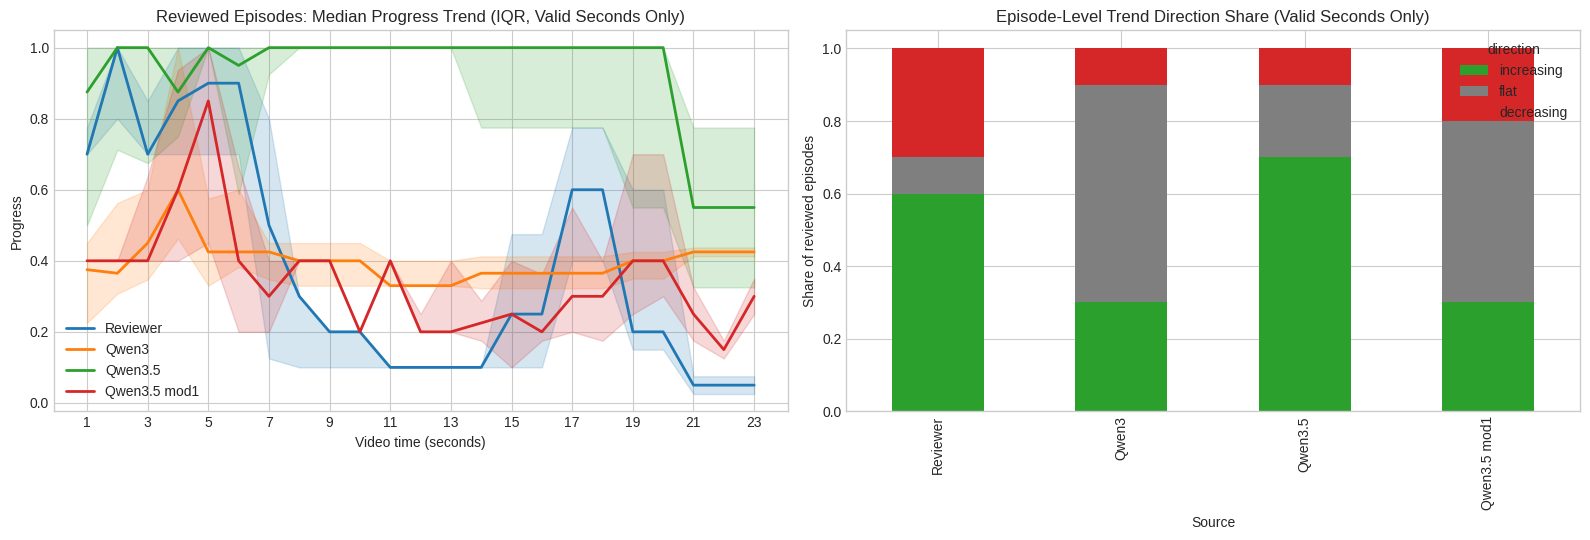

### Trend Direction Table (episode-level slopes, valid seconds only)

,source,episode_key,slope,direction,n_valid_points,max_second_included
0,Qwen3,20260526T044728Z:ep_10,8.714286e-02,increasing,6,6
1,Qwen3,20260526T044728Z:ep_11,2.500000e-02,increasing,5,5
2,Qwen3,20260527T200712Z:ep_2,-1.316703e-17,flat,6,6
3,Qwen3,20260527T200712Z:ep_3,-5.335968e-03,flat,23,23
4,Qwen3,20260528T011322Z:ep_11,2.637363e-03,flat,13,13
5,Qwen3,20260528T011322Z:ep_12,7.000000e-02,increasing,5,5
6,Qwen3,20260528T023001Z:ep_2,7.142857e-03,flat,7,7
7,Qwen3,20260528T023001Z:ep_3,7.361660e-03,flat,23,23
8,Qwen3,20260528T085356Z:ep_2,-1.016838e-17,flat,17,18
9,Qwen3,20260528T085356Z:ep_3,-2.175439e-02,decreasing,19,20


In [2]:
# Trend visualizations for reviewed episodes: median trajectory + direction class shares (video-length constrained).
if 'PROGRESS_LONG_DF' not in globals() or PROGRESS_LONG_DF.empty:
    raise ValueError('Run the previous cell to build PROGRESS_LONG_DF.')

plt.style.use('seaborn-v0_8-whitegrid')
order = ['Reviewer', 'Qwen3', 'Qwen3.5', 'Qwen3.5 mod1']
palette = {'Reviewer':'#1f77b4','Qwen3':'#ff7f0e','Qwen3.5':'#2ca02c','Qwen3.5 mod1':'#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: median trend with IQR shading, using only seconds <= episode max_valid_second
for src in order:
    g = PROGRESS_LONG_DF[PROGRESS_LONG_DF['source'].eq(src)]
    if g.empty:
        continue
    q = g.groupby('second')['progress'].agg(
        p25=lambda x: np.nanpercentile(x, 25),
        p50=lambda x: np.nanpercentile(x, 50),
        p75=lambda x: np.nanpercentile(x, 75),
    ).reset_index()
    axes[0].plot(q['second'], q['p50'], label=src, color=palette[src], linewidth=2)
    axes[0].fill_between(q['second'], q['p25'], q['p75'], color=palette[src], alpha=0.18)

max_sec_seen = int(PROGRESS_LONG_DF['second'].max())
axes[0].set_title('Reviewed Episodes: Median Progress Trend (IQR, Valid Seconds Only)')
axes[0].set_xlabel('Video time (seconds)')
axes[0].set_ylabel('Progress')
axes[0].set_xticks(range(1, max_sec_seen + 1, 2 if max_sec_seen > 10 else 1))
axes[0].legend(loc='best')

# Right: trend direction class by episode and source (already constrained by valid seconds)
trend_rows = []
for src in order:
    src_df = PROGRESS_LONG_DF[PROGRESS_LONG_DF['source'].eq(src)].copy()
    for ep, g in src_df.groupby('episode_key'):
        if g['second'].nunique() < 2:
            continue
        gg = g.sort_values('second')
        x = gg['second'].to_numpy()
        y = gg['progress'].to_numpy()
        slope = np.polyfit(x, y, 1)[0] if len(x) >= 2 else np.nan
        direction = 'flat'
        if pd.notna(slope) and slope > 0.01:
            direction = 'increasing'
        elif pd.notna(slope) and slope < -0.01:
            direction = 'decreasing'
        trend_rows.append({
            'source': src,
            'episode_key': ep,
            'slope': slope,
            'direction': direction,
            'n_valid_points': int(g['second'].nunique()),
            'max_second_included': int(g['second'].max()),
        })

trend_df = pd.DataFrame(trend_rows)
if trend_df.empty:
    axes[1].text(0.5, 0.5, 'No trend rows to display', ha='center', va='center')
    axes[1].axis('off')
else:
    share = (
        trend_df.groupby(['source', 'direction']).size().rename('n').reset_index()
        .pivot(index='source', columns='direction', values='n').fillna(0)
    )
    for d in ['increasing', 'flat', 'decreasing']:
        if d not in share.columns:
            share[d] = 0
    share = share[['increasing', 'flat', 'decreasing']]
    share = share.div(share.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    share = share.reindex(order).fillna(0)
    share.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#7f7f7f', '#d62728'])
    axes[1].set_title('Episode-Level Trend Direction Share (Valid Seconds Only)')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Share of reviewed episodes')
    axes[1].legend(title='direction', loc='upper right')

plt.tight_layout()
plt.show()

if not trend_df.empty:
    display(Markdown('### Trend Direction Table (episode-level slopes, valid seconds only)'))
    display(trend_df.sort_values(['source', 'episode_key']).reset_index(drop=True).head(40))

## Node-Aligned Timeline View
To align trend behavior with task structure, we map each second to the current reviewer node using `node_i_reviewer_completion_time`.
The plot below overlays reviewer/model progress curves with node spans and completion boundaries for a reviewed episode.

Interpretation guide:
1. Rising segments inside a node span suggest accumulating confidence/progress before completion.
2. Abrupt changes near node boundaries may indicate transition sensitivity or timing misalignment.
3. Persistent gaps between reviewer and model lines can reveal systematic calibration differences.

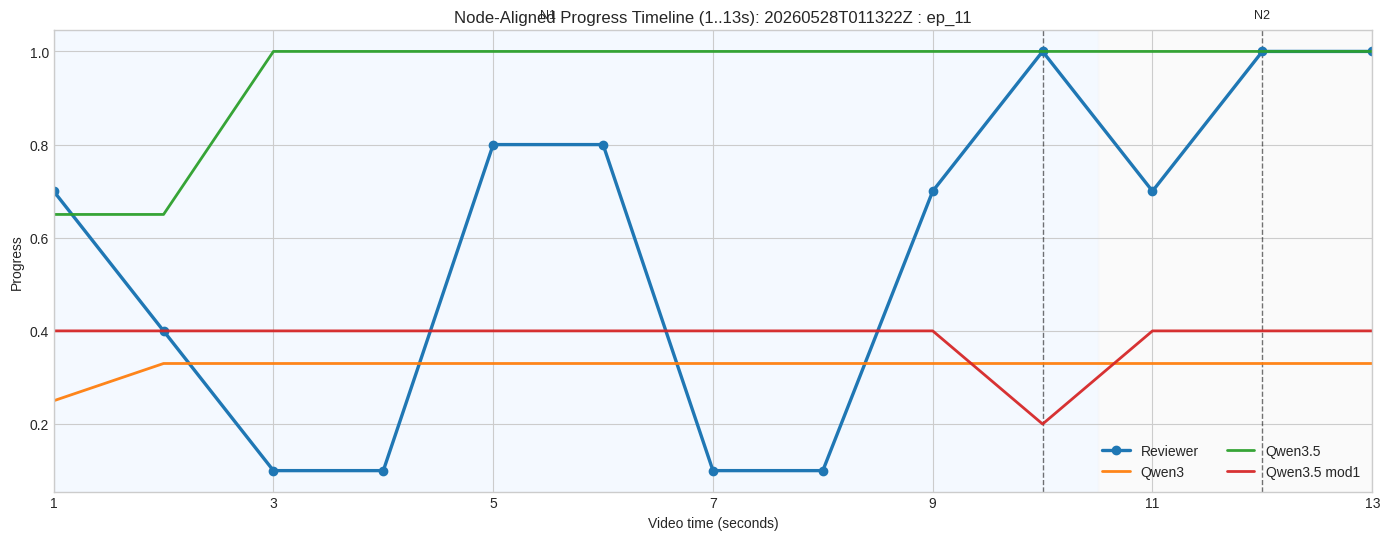

### Second-by-Second Node Alignment Table (1..13s)

,second,current_node,within_video_length,reviewer,qwen3,qwen3_5,qwen3_5_mod1
0,1,node_action_grasp_lemon,True,0.7,0.25,0.65,0.4
1,2,node_action_grasp_lemon,True,0.4,0.33,0.65,0.4
2,3,node_action_grasp_lemon,True,0.1,0.33,1.00,0.4
3,4,node_action_grasp_lemon,True,0.1,0.33,1.00,0.4
4,5,node_action_grasp_lemon,True,0.8,0.33,1.00,0.4
5,6,node_action_grasp_lemon,True,0.8,0.33,1.00,0.4
6,7,node_action_grasp_lemon,True,0.1,0.33,1.00,0.4
7,8,node_action_grasp_lemon,True,0.1,0.33,1.00,0.4
8,9,node_action_grasp_lemon,True,0.7,0.33,1.00,0.4
9,10,node_action_grasp_lemon,True,1.0,0.33,1.00,0.2


In [3]:
# Node-aligned episode timeline: progress curves overlaid with current-node spans (video-length constrained).
if 'PROGRESS_REVIEWED_DF' not in globals() or PROGRESS_REVIEWED_DF.empty:
    raise ValueError('Run the reviewed dataset loading cell first.')

def _to_sec(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if not s or s.lower() in {'nan','none','null'}:
        return np.nan
    if ':' in s:
        parts = s.split(':')
        if len(parts) >= 2:
            try:
                mm = int(float(parts[-2]))
                ss = int(float(parts[-1]))
                return mm * 60 + ss
            except Exception:
                return np.nan
    try:
        return int(float(s))
    except Exception:
        return np.nan

# Prefer the user's recent debug episode if present; otherwise use first reviewed row.
sel = PROGRESS_REVIEWED_DF[
    PROGRESS_REVIEWED_DF['run_tag'].astype(str).eq('20260528T011322Z')
    & pd.to_numeric(PROGRESS_REVIEWED_DF['episode_index'], errors='coerce').eq(11)
] .copy()
if sel.empty:
    sel = PROGRESS_REVIEWED_DF.head(1).copy()

row = sel.iloc[0]
episode_title = f"{row.get('run_tag','')} : ep_{int(pd.to_numeric(row.get('episode_index',np.nan), errors='coerce'))}"
episode_max_second = int(_episode_max_second(row, hard_cap=25))

n_nodes = int(pd.to_numeric(row.get('bt_action_nodes', 0), errors='coerce') or 0)
n_nodes = max(0, n_nodes)
node_names = []
node_complete_secs = []
for i in range(1, n_nodes + 1):
    node_names.append(str(row.get(f'node_{i}_node_id', f'node_{i}')) or f'node_{i}')
    node_complete_secs.append(_to_sec(row.get(f'node_{i}_reviewer_completion_time', np.nan)))

# Build node spans [start, end] using reviewer completion times, clipped to episode_max_second.
spans = []
start = 1
for i, name in enumerate(node_names, start=1):
    end = node_complete_secs[i - 1] if i - 1 < len(node_complete_secs) else np.nan
    end = int(end) if pd.notna(end) else episode_max_second
    end = min(max(end, start), episode_max_second)
    spans.append({'node_idx': i, 'node_name': name, 'start': start, 'end': end})
    start = min(end + 1, episode_max_second)
if spans and spans[-1]['end'] < episode_max_second:
    spans[-1]['end'] = episode_max_second

sec = np.arange(1, episode_max_second + 1)
y_reviewer = [pd.to_numeric(row.get(f'{s}s_reviewer', np.nan), errors='coerce') for s in sec]
y_q3 = [pd.to_numeric(row.get(f'{s}s_qwen3', np.nan), errors='coerce') for s in sec]
y_q35 = [pd.to_numeric(row.get(f'{s}s_qwen3_5', np.nan), errors='coerce') for s in sec]
y_q35m1 = [pd.to_numeric(row.get(f'{s}s_qwen3_5_mod1', np.nan), errors='coerce') for s in sec]

fig, ax = plt.subplots(figsize=(14, 5.5))
colors = ['#eef6ff', '#f7f7f7']
for i, sp in enumerate(spans):
    ax.axvspan(sp['start'] - 0.5, sp['end'] + 0.5, color=colors[i % 2], alpha=0.6, zorder=0)
    ax.text((sp['start'] + sp['end']) / 2, 1.02, f"N{i+1}", ha='center', va='bottom', fontsize=9, transform=ax.get_xaxis_transform())

for t in node_complete_secs:
    if pd.notna(t) and 1 <= int(t) <= episode_max_second:
        ax.axvline(int(t), color='black', linestyle='--', linewidth=1, alpha=0.55)

ax.plot(sec, y_reviewer, label='Reviewer', color='#1f77b4', linewidth=2.4, marker='o')
ax.plot(sec, y_q3, label='Qwen3', color='#ff7f0e', linewidth=2.0, alpha=0.95)
ax.plot(sec, y_q35, label='Qwen3.5', color='#2ca02c', linewidth=2.0, alpha=0.95)
ax.plot(sec, y_q35m1, label='Qwen3.5 mod1', color='#d62728', linewidth=2.0, alpha=0.95)

ax.set_title(f'Node-Aligned Progress Timeline (1..{episode_max_second}s): {episode_title}')
ax.set_xlabel('Video time (seconds)')
ax.set_ylabel('Progress')
ax.set_xlim(1, episode_max_second)
ax.set_xticks(range(1, episode_max_second + 1, 1 if episode_max_second <= 12 else 2))
ax.legend(loc='lower right', ncol=2)
plt.tight_layout()
plt.show()

alignment_rows = []
for s in sec:
    node_here = ''
    for sp in spans:
        if sp['start'] <= s <= sp['end']:
            node_here = sp['node_name']
            break
    alignment_rows.append({
        'second': int(s),
        'current_node': node_here,
        'within_video_length': True,
        'reviewer': y_reviewer[s - 1],
        'qwen3': y_q3[s - 1],
        'qwen3_5': y_q35[s - 1],
        'qwen3_5_mod1': y_q35m1[s - 1],
    })

NODE_ALIGNED_EPISODE_TABLE = pd.DataFrame(alignment_rows)
display(Markdown(f'### Second-by-Second Node Alignment Table (1..{episode_max_second}s)'))
display(NODE_ALIGNED_EPISODE_TABLE)

## Best Reviewer vs Qwen3.5 mod1 Alignment
We rank reviewed episodes by overlap-aware error between reviewer and qwen3_5_mod1 across seconds 1..25.
Primary score is MAE (lower is better); RMSE and overlap count are shown for context.
The best-aligned episode is then plotted with Reviewer, Qwen3.5 mod1, and Qwen3 for side-by-side trend comparison.

### Top Alignment Episodes (Reviewer vs Qwen3.5 mod1, valid seconds only)

,scenario_id,run_tag,episode_index,episode_id,episode_dir,max_valid_second,overlap_seconds,mae_reviewer_vs_mod1,rmse_reviewer_vs_mod1,corr_reviewer_vs_mod1
0,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,3,20260527T200712Z:ep_3,PosttrainPnPNovelFromCuttingboardToBasketSplit...,23,23,0.082609,0.145960,0.735431
1,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,10,20260526T044728Z:ep_10,PosttrainPnPNovelFromPlateToPlateSplitA_GR1Arm...,6,6,0.133333,0.230940,0.798584
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20260528T085356Z:ep_3,PnPCanToDrawerClose_GR1ArmsAndWaistFourierHand...,20,20,0.215000,0.291976,0.640151
3,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,3,20260528T023001Z:ep_3,PosttrainPnPNovelFromCuttingboardToBasketSplit...,23,23,0.247826,0.298183,0.308525
4,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,PnPCanToDrawerClose_GR1ArmsAndWaistFourierHand...,18,18,0.277778,0.349205,0.545811
5,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,11,20260526T044728Z:ep_11,PosttrainPnPNovelFromPlateToPlateSplitA_GR1Arm...,5,5,0.350000,0.393065,0.037905
6,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,20260527T200712Z:ep_2,PosttrainPnPNovelFromCuttingboardToBasketSplit...,6,6,0.358333,0.447679,0.353401
7,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,11,20260528T011322Z:ep_11,PosttrainPnPNovelFromPlateToPlateSplitA_GR1Arm...,13,13,0.376923,0.421536,-0.345645
8,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,PosttrainPnPNovelFromPlateToPlateSplitA_GR1Arm...,5,5,0.480000,0.501996,-0.612372
9,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,2,20260528T023001Z:ep_2,PosttrainPnPNovelFromCuttingboardToBasketSplit...,7,7,0.542857,0.573212,-0.801235


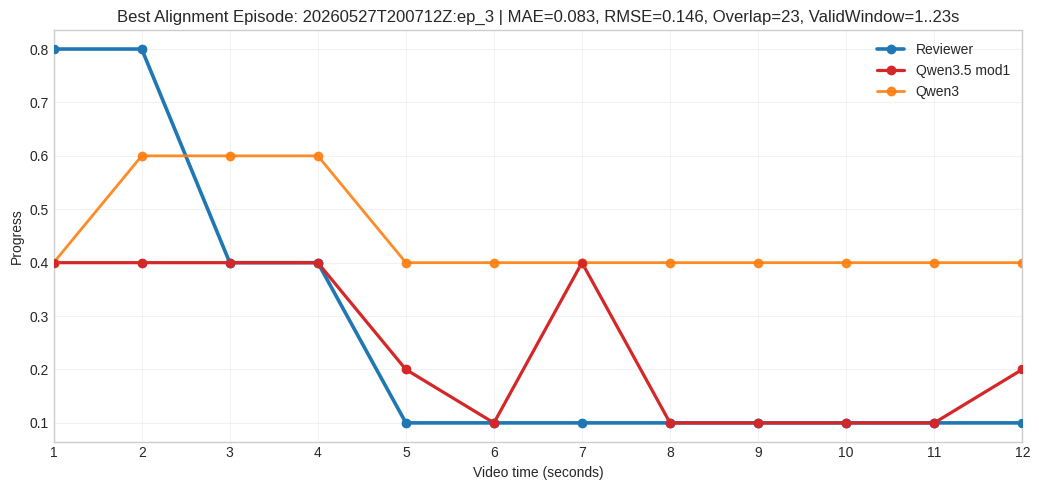

### Best Episode Second-by-Second Table (1..12s shown; valid window is 1..23s)

,second,within_video_length,reviewer,qwen3_5_mod1,qwen3,scoring_overlap_reviewer_mod1
0,1,True,0.8,0.4,0.4,True
1,2,True,0.8,0.4,0.6,True
2,3,True,0.4,0.4,0.6,True
3,4,True,0.4,0.4,0.6,True
4,5,True,0.1,0.2,0.4,True
5,6,True,0.1,0.1,0.4,True
6,7,True,0.1,0.4,0.4,True
7,8,True,0.1,0.1,0.4,True
8,9,True,0.1,0.1,0.4,True
9,10,True,0.1,0.1,0.4,True


In [4]:
# Find the reviewed episode with strongest reviewer vs qwen3.5 mod1 alignment and chart it (video-length constrained).
if 'PROGRESS_REVIEWED_DF' not in globals() or PROGRESS_REVIEWED_DF.empty:
    raise ValueError('Run the reviewed progress loading cell first.')

PLOT_MAX_SEC = 12
score_rows = []
for _, row in PROGRESS_REVIEWED_DF.iterrows():
    max_valid_second = int(_episode_max_second(row, hard_cap=25))
    secs = np.arange(1, max_valid_second + 1, dtype=int)

    reviewer = np.array([pd.to_numeric(row.get(f'{s}s_reviewer', np.nan), errors='coerce') for s in secs], dtype=float)
    mod1 = np.array([pd.to_numeric(row.get(f'{s}s_qwen3_5_mod1', np.nan), errors='coerce') for s in secs], dtype=float)
    qwen3 = np.array([pd.to_numeric(row.get(f'{s}s_qwen3', np.nan), errors='coerce') for s in secs], dtype=float)

    mask = ~np.isnan(reviewer) & ~np.isnan(mod1)
    overlap = int(mask.sum())
    if overlap < 3:
        continue

    diff = reviewer[mask] - mod1[mask]
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    corr = float(np.corrcoef(reviewer[mask], mod1[mask])[0, 1]) if overlap >= 3 else np.nan

    score_rows.append({
        'scenario_id': row.get('scenario_id', ''),
        'run_tag': row.get('run_tag', ''),
        'episode_index': int(pd.to_numeric(row.get('episode_index', np.nan), errors='coerce')),
        'episode_id': row.get('episode_id', ''),
        'episode_dir': row.get('episode_dir', ''),
        'max_valid_second': max_valid_second,
        'overlap_seconds': overlap,
        'mae_reviewer_vs_mod1': mae,
        'rmse_reviewer_vs_mod1': rmse,
        'corr_reviewer_vs_mod1': corr,
    })

ALIGNMENT_SCORES = pd.DataFrame(score_rows)
if ALIGNMENT_SCORES.empty:
    raise ValueError('No reviewed episodes with enough overlap between reviewer and qwen3_5_mod1 within video_length_seconds.')

ALIGNMENT_SCORES = ALIGNMENT_SCORES.sort_values(
    ['mae_reviewer_vs_mod1', 'rmse_reviewer_vs_mod1', 'overlap_seconds'],
    ascending=[True, True, False]
)
BEST_ALIGNMENT_ROW = ALIGNMENT_SCORES.iloc[0].copy()

display(Markdown('### Top Alignment Episodes (Reviewer vs Qwen3.5 mod1, valid seconds only)'))
display(ALIGNMENT_SCORES.head(10).reset_index(drop=True))

best_mask = (
    PROGRESS_REVIEWED_DF['run_tag'].astype(str).eq(str(BEST_ALIGNMENT_ROW['run_tag']))
    & pd.to_numeric(PROGRESS_REVIEWED_DF['episode_index'], errors='coerce').eq(int(BEST_ALIGNMENT_ROW['episode_index']))
)
best_ep = PROGRESS_REVIEWED_DF[best_mask].head(1)
if best_ep.empty:
    raise ValueError('Best alignment episode not found in PROGRESS_REVIEWED_DF.')
best_ep = best_ep.iloc[0]

best_max_sec = int(_episode_max_second(best_ep, hard_cap=25))
secs = np.arange(1, best_max_sec + 1, dtype=int)
x = secs.astype(float)
y_reviewer = np.array([pd.to_numeric(best_ep.get(f'{s}s_reviewer', np.nan), errors='coerce') for s in secs], dtype=float)
y_mod1 = np.array([pd.to_numeric(best_ep.get(f'{s}s_qwen3_5_mod1', np.nan), errors='coerce') for s in secs], dtype=float)
y_q3 = np.array([pd.to_numeric(best_ep.get(f'{s}s_qwen3', np.nan), errors='coerce') for s in secs], dtype=float)

plot_max = int(min(PLOT_MAX_SEC, best_max_sec))
plot_mask = x <= plot_max
x_plot = x[plot_mask]
y_reviewer_plot = y_reviewer[plot_mask]
y_mod1_plot = y_mod1[plot_mask]
y_q3_plot = y_q3[plot_mask]

fig, ax = plt.subplots(figsize=(10.5, 5.0))
ax.plot(x_plot, y_reviewer_plot, marker='o', linewidth=2.6, color='#1f77b4', label='Reviewer')
ax.plot(x_plot, y_mod1_plot, marker='o', linewidth=2.3, color='#d62728', label='Qwen3.5 mod1')
ax.plot(x_plot, y_q3_plot, marker='o', linewidth=2.0, color='#ff7f0e', alpha=0.9, label='Qwen3')

# Highlight overlap points used for scoring (on plotted window).
score_mask = ~np.isnan(y_reviewer) & ~np.isnan(y_mod1)
score_mask_plot = score_mask[plot_mask]
ax.scatter(x_plot[score_mask_plot], y_reviewer_plot[score_mask_plot], color='#1f77b4', s=30, zorder=4)
ax.scatter(x_plot[score_mask_plot], y_mod1_plot[score_mask_plot], color='#d62728', s=30, zorder=4)

title = (
    f"Best Alignment Episode: {BEST_ALIGNMENT_ROW['run_tag']}:ep_{int(BEST_ALIGNMENT_ROW['episode_index'])} "
    f"| MAE={BEST_ALIGNMENT_ROW['mae_reviewer_vs_mod1']:.3f}, "
    f"RMSE={BEST_ALIGNMENT_ROW['rmse_reviewer_vs_mod1']:.3f}, "
    f"Overlap={int(BEST_ALIGNMENT_ROW['overlap_seconds'])}, "
    f"ValidWindow=1..{best_max_sec}s"
)
ax.set_title(title)
ax.set_xlabel('Video time (seconds)')
ax.set_ylabel('Progress')
ax.set_xlim(1, plot_max)
ax.set_xticks(range(1, plot_max + 1, 1))
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

BEST_ALIGNMENT_TIMESERIES = pd.DataFrame({
    'second': secs,
    'within_video_length': True,
    'reviewer': y_reviewer,
    'qwen3_5_mod1': y_mod1,
    'qwen3': y_q3,
    'scoring_overlap_reviewer_mod1': score_mask,
})
display(Markdown(f'### Best Episode Second-by-Second Table (1..{plot_max}s shown; valid window is 1..{best_max_sec}s)'))
display(BEST_ALIGNMENT_TIMESERIES[BEST_ALIGNMENT_TIMESERIES['second'] <= plot_max])

## Video Length Constraint Diagnostics
This section audits the `video_length_seconds` filter across reviewed episodes.
It makes the inclusion rule explicit: only seconds `1..video_length_seconds` are eligible per episode; higher-second fields are discarded from trend/alignment calculations.

### What this adds
1. Distribution of episode `video_length_seconds` values.
2. Kept vs discarded non-NaN progress points per source.
3. Episode-level table showing valid window size and discarded points.

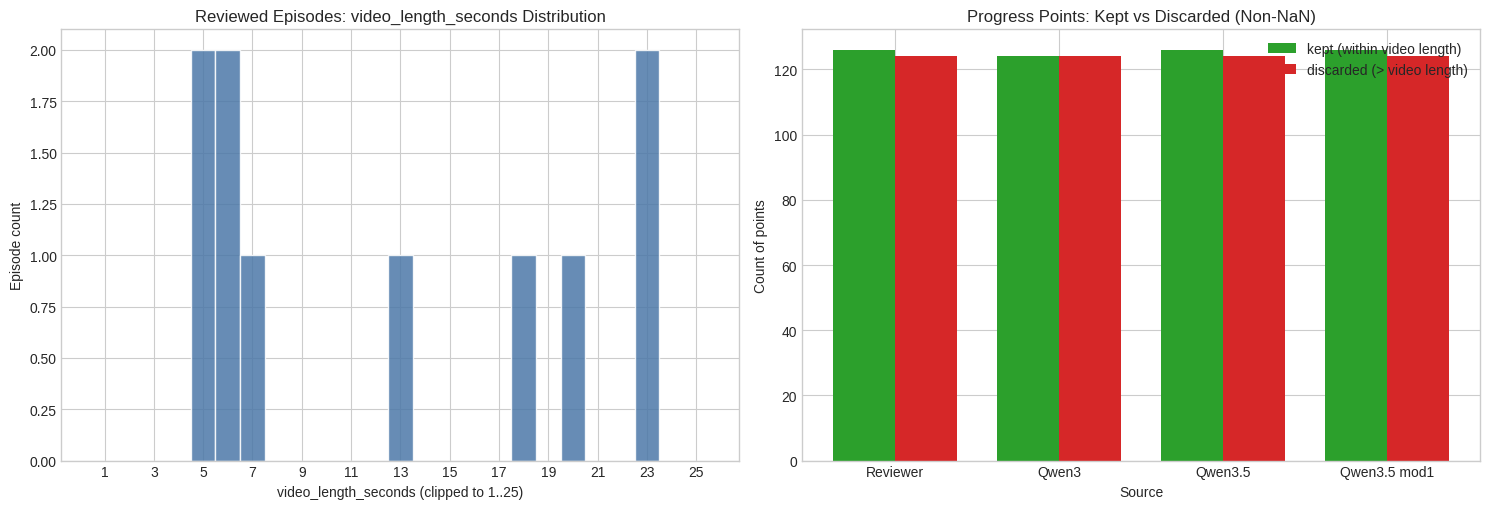

### Video Length Gating Summary by Source

,source,valid_non_nan_points,discarded_non_nan_points,discarded_pct_of_non_nan
0,Reviewer,126,124,0.496
1,Qwen3,124,124,0.500
2,Qwen3.5,126,124,0.496
3,Qwen3.5 mod1,126,124,0.496


### Episodes With Highest Discarded Fraction (top 25)

,episode_key,scenario_id,run_tag,episode_index,video_length_seconds,max_valid_second,valid_non_nan_points,discarded_non_nan_points,total_non_nan_points,discarded_fraction_non_nan
0,20260526T044728Z:ep_11,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,11,5.0,5,20,80,100,0.800000
1,20260528T011322Z:ep_12,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,5.0,5,20,80,100,0.800000
2,20260526T044728Z:ep_10,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260526T044728Z,10,6.0,6,24,76,100,0.760000
3,20260527T200712Z:ep_2,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,6.0,6,24,76,100,0.760000
4,20260528T023001Z:ep_2,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,2,7.0,7,28,72,100,0.720000
5,20260528T011322Z:ep_11,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,11,13.0,13,52,48,100,0.480000
6,20260528T085356Z:ep_2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,18.0,18,71,28,99,0.282828
7,20260528T085356Z:ep_3,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20.0,20,79,20,99,0.202020
8,20260527T200712Z:ep_3,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,3,23.0,23,92,8,100,0.080000
9,20260528T023001Z:ep_3,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260528T023001Z,3,23.0,23,92,8,100,0.080000


### Episodes With Full Coverage (no discarded non-NaN points; top 25)

,episode_key,scenario_id,run_tag,episode_index,video_length_seconds,max_valid_second,valid_non_nan_points,discarded_non_nan_points,total_non_nan_points,discarded_fraction_non_nan


In [5]:
# Diagnostics charts/tables for video_length_seconds gating across all reviewed episodes.
required = ['PROGRESS_REVIEWED_DF', 'PROGRESS_LONG_DF_ALL', 'EPISODE_SOURCE_VALIDITY_DF']
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f'Run the reviewed dataset cell first. Missing: {missing}')

if PROGRESS_REVIEWED_DF.empty:
    raise ValueError('No reviewed episodes available for diagnostics.')

plt.style.use('seaborn-v0_8-whitegrid')

# Episode-level video length distribution
vl = pd.to_numeric(PROGRESS_REVIEWED_DF['video_length_seconds'], errors='coerce').dropna()
if vl.empty:
    raise ValueError('video_length_seconds is missing/NaN for all reviewed episodes.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# Left: histogram of video lengths
bins = np.arange(0.5, 25.6, 1.0)
axes[0].hist(vl.clip(1, 25), bins=bins, color='#4c78a8', alpha=0.85, edgecolor='white')
axes[0].set_title('Reviewed Episodes: video_length_seconds Distribution')
axes[0].set_xlabel('video_length_seconds (clipped to 1..25)')
axes[0].set_ylabel('Episode count')
axes[0].set_xticks(range(1, 26, 2))

# Right: kept vs discarded non-NaN progress points by source
source_order = ['Reviewer', 'Qwen3', 'Qwen3.5', 'Qwen3.5 mod1']
src_counts = (
    EPISODE_SOURCE_VALIDITY_DF.groupby('source')[['valid_non_nan_points', 'discarded_non_nan_points']]
    .sum()
    .reindex(source_order)
    .fillna(0)
    .astype(int)
)
x = np.arange(len(src_counts.index))
w = 0.38
axes[1].bar(x - w/2, src_counts['valid_non_nan_points'], width=w, color='#2ca02c', label='kept (within video length)')
axes[1].bar(x + w/2, src_counts['discarded_non_nan_points'], width=w, color='#d62728', label='discarded (> video length)')
axes[1].set_title('Progress Points: Kept vs Discarded (Non-NaN)')
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count of points')
axes[1].set_xticks(x)
axes[1].set_xticklabels(src_counts.index, rotation=0)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

# Build episode-level diagnostics table
episode_validity = (
    EPISODE_SOURCE_VALIDITY_DF.groupby(['episode_key', 'scenario_id', 'run_tag', 'episode_index', 'video_length_seconds', 'max_valid_second'], as_index=False)
    [['valid_non_nan_points', 'discarded_non_nan_points']]
    .sum()
)
episode_validity['total_non_nan_points'] = episode_validity['valid_non_nan_points'] + episode_validity['discarded_non_nan_points']
episode_validity['discarded_fraction_non_nan'] = (
    episode_validity['discarded_non_nan_points']
    / episode_validity['total_non_nan_points'].replace(0, np.nan)
).fillna(0.0)
episode_validity = episode_validity.sort_values(
    ['discarded_fraction_non_nan', 'discarded_non_nan_points', 'episode_key'],
    ascending=[False, False, True]
).reset_index(drop=True)

VIDEO_LENGTH_DIAGNOSTICS_DF = episode_validity

display(Markdown('### Video Length Gating Summary by Source'))
src_summary = src_counts.reset_index().rename(columns={'index': 'source'})
src_summary['discarded_pct_of_non_nan'] = (
    src_summary['discarded_non_nan_points']
    / (src_summary['valid_non_nan_points'] + src_summary['discarded_non_nan_points']).replace(0, np.nan)
).fillna(0.0)
display(src_summary)

display(Markdown('### Episodes With Highest Discarded Fraction (top 25)'))
display(VIDEO_LENGTH_DIAGNOSTICS_DF.head(25))

display(Markdown('### Episodes With Full Coverage (no discarded non-NaN points; top 25)'))
full_cov = VIDEO_LENGTH_DIAGNOSTICS_DF[VIDEO_LENGTH_DIAGNOSTICS_DF['discarded_non_nan_points'].eq(0)].head(25)
display(full_cov)

## Progress Score Distribution and Optimism/Pessimism Profile
This table summarizes score distributions by source using only valid points inside each episode's `video_length_seconds` window.

Interpretation hints:
1. Higher `% > 0.5` and lower `% < 0.5` indicate a more optimistic scoring tendency.
2. Lower `% > 0.5` and higher `% < 0.5` indicate a more pessimistic tendency.
3. `Balance(>0.5 - <0.5)` is a signed optimism index (positive = more optimistic, negative = more pessimistic).

In [6]:
# Build per-source progress score distribution table (valid-window points only).
if 'PROGRESS_LONG_DF' not in globals() or PROGRESS_LONG_DF.empty:
    raise ValueError('Run the reviewed progress loading/processing cells first to build PROGRESS_LONG_DF.')

dist_df = PROGRESS_LONG_DF.dropna(subset=['progress']).copy()

def _iqr(s):
    return float(s.quantile(0.75) - s.quantile(0.25))

def _pct_mask(s, mask):
    n = s.notna().sum()
    if n == 0:
        return np.nan
    return float(mask.sum() / n)

summary_rows = []
for src, g in dist_df.groupby('source'):
    s = pd.to_numeric(g['progress'], errors='coerce').dropna()
    if s.empty:
        continue

    pct_lt_05 = _pct_mask(s, s < 0.5)
    pct_eq_05 = _pct_mask(s, np.isclose(s, 0.5, atol=1e-12))
    pct_gt_05 = _pct_mask(s, s > 0.5)

    summary_rows.append({
        'source': src,
        'N_points': int(s.shape[0]),
        'Mean': float(s.mean()),
        'Median': float(s.median()),
        'SD': float(s.std(ddof=1)) if s.shape[0] > 1 else 0.0,
        'IQR': _iqr(s),
        'Min': float(s.min()),
        'Max': float(s.max()),
        '%<0.5': pct_lt_05,
        '%=0.5': pct_eq_05,
        '%>0.5': pct_gt_05,
        'Balance(>0.5-<0.5)': float(pct_gt_05 - pct_lt_05),
    })

PROGRESS_DISTRIBUTION_TABLE = pd.DataFrame(summary_rows)
if PROGRESS_DISTRIBUTION_TABLE.empty:
    raise ValueError('No distribution rows were computed from PROGRESS_LONG_DF.')

# Keep a stable source ordering if available, otherwise sort alphabetically.
source_order = ['Reviewer', 'Qwen3', 'Qwen3.5', 'Qwen3.5 mod1']
existing_order = [s for s in source_order if s in set(PROGRESS_DISTRIBUTION_TABLE['source'])]
remaining = sorted([s for s in PROGRESS_DISTRIBUTION_TABLE['source'] if s not in set(existing_order)])
PROGRESS_DISTRIBUTION_TABLE['__order'] = PROGRESS_DISTRIBUTION_TABLE['source'].map(
    {k: i for i, k in enumerate(existing_order + remaining)}
)
PROGRESS_DISTRIBUTION_TABLE = PROGRESS_DISTRIBUTION_TABLE.sort_values('__order').drop(columns='__order').reset_index(drop=True)

display(Markdown('### Progress Score Distribution by Source (Valid Seconds Only)'))
display(PROGRESS_DISTRIBUTION_TABLE)

# Optional compact optimism/pessimism ranking view.
optimism_rank = PROGRESS_DISTRIBUTION_TABLE[
    ['source', 'N_points', '%<0.5', '%>0.5', 'Balance(>0.5-<0.5)', 'Mean', 'Median']
] .sort_values('Balance(>0.5-<0.5)', ascending=False).reset_index(drop=True)

display(Markdown('### Optimism/Pessimism Ranking (higher balance = more optimistic)'))
display(optimism_rank)

### Progress Score Distribution by Source (Valid Seconds Only)

,source,N_points,Mean,Median,SD,IQR,Min,Max,%<0.5,%=0.5,%>0.5,Balance(>0.5-<0.5)
0,Reviewer,126,0.529365,0.7,0.371821,0.70,0.0,1.0,0.444444,0.015873,0.539683,0.095238
1,Qwen3,124,0.440081,0.4,0.191971,0.12,0.1,1.0,0.782258,0.016129,0.201613,-0.580645
2,Qwen3.5,126,0.790079,1.0,0.348024,0.25,0.1,1.0,0.214286,0.000000,0.785714,0.571429
3,Qwen3.5 mod1,126,0.412698,0.4,0.257522,0.20,0.1,1.0,0.801587,0.000000,0.198413,-0.603175


### Optimism/Pessimism Ranking (higher balance = more optimistic)

,source,N_points,%<0.5,%>0.5,Balance(>0.5-<0.5),Mean,Median
0,Qwen3.5,126,0.214286,0.785714,0.571429,0.790079,1.0
1,Reviewer,126,0.444444,0.539683,0.095238,0.529365,0.7
2,Qwen3,124,0.782258,0.201613,-0.580645,0.440081,0.4
3,Qwen3.5 mod1,126,0.801587,0.198413,-0.603175,0.412698,0.4


## Movement-Direction Agreement vs Reviewer
We compare each model to Reviewer on transition direction using:
`delta_progress_t = progress_t - progress_(t-1)` within each episode.

Classification rule (`DELTA_THRESHOLD`):
1. `delta > threshold` -> `increasing`
2. `delta < -threshold` -> `decreasing`
3. otherwise -> `flat`

Agreement is computed at each valid transition where both Reviewer and model deltas are available.

### Movement-Direction Agreement vs Reviewer (threshold = 0.05)

,model_source,N_transitions,agreement_n,agreement_rate,reviewer_increasing_rate,reviewer_flat_rate,reviewer_decreasing_rate,model_increasing_rate,model_flat_rate,model_decreasing_rate,optimistic_rate,pessimistic_rate,neutral_bias_rate,optimism_minus_pessimism
0,Qwen3,114,63,0.552632,0.201754,0.605263,0.192982,0.105263,0.850877,0.04386,0.245614,0.228070,0.526316,0.017544
1,Qwen3.5 mod1,116,47,0.405172,0.215517,0.594828,0.189655,0.267241,0.482759,0.25000,0.344828,0.344828,0.310345,0.000000


### Reviewer-to-Model Direction Confusion Heatmaps (row-normalized)

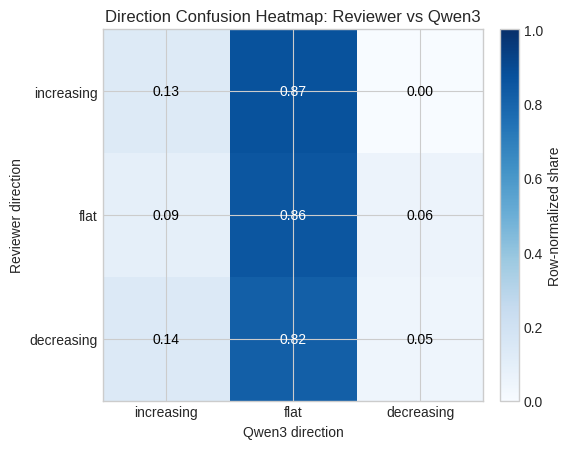

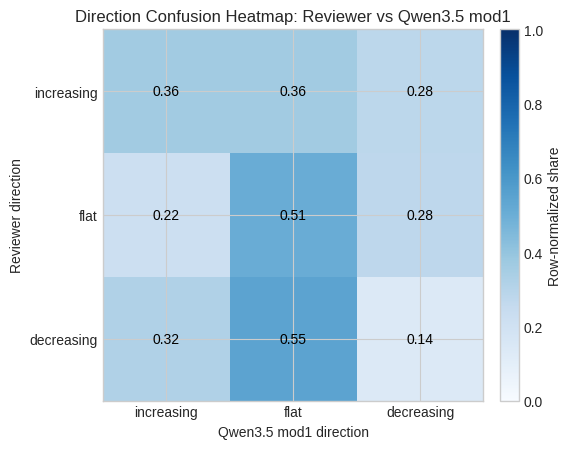

### Reviewer-to-Model Direction Confusion Tables (row-normalized)

#### Qwen3

Qwen3_direction,increasing,flat,decreasing
reviewer_direction,,,
increasing,0.130,0.870,0.000
flat,0.087,0.855,0.058
decreasing,0.136,0.818,0.045


#### Qwen3.5 mod1

Qwen3.5 mod1_direction,increasing,flat,decreasing
reviewer_direction,,,
increasing,0.360,0.360,0.280
flat,0.217,0.507,0.275
decreasing,0.318,0.545,0.136


### Reviewer-to-Model Direction Confusion Tables (raw transition counts)

#### Qwen3

Qwen3_direction,increasing,flat,decreasing
reviewer_direction,,,
increasing,3,20,0
flat,6,59,4
decreasing,3,18,1


#### Qwen3.5 mod1

Qwen3.5 mod1_direction,increasing,flat,decreasing
reviewer_direction,,,
increasing,9,9,7
flat,15,35,19
decreasing,7,12,3


In [10]:
# Movement-direction agreement between each model and Reviewer using delta_progress_t.
if 'PROGRESS_LONG_DF' not in globals() or PROGRESS_LONG_DF.empty:
    raise ValueError('Run the reviewed progress processing cells first to build PROGRESS_LONG_DF.')

DELTA_THRESHOLD = 0.05
REVIEWER = 'Reviewer'
MODEL_SOURCES = [s for s in ['Qwen3', 'Qwen3.5 mod1'] if s in PROGRESS_LONG_DF['source'].unique()]

if REVIEWER not in PROGRESS_LONG_DF['source'].unique():
    raise ValueError('Reviewer source is missing from PROGRESS_LONG_DF.')
if not MODEL_SOURCES:
    raise ValueError('No model sources found in PROGRESS_LONG_DF.')

wide = (
    PROGRESS_LONG_DF[['episode_key', 'second', 'source', 'progress']]
    .pivot_table(index=['episode_key', 'second'], columns='source', values='progress', aggfunc='mean')
    .reset_index()
    .sort_values(['episode_key', 'second'])
)

def classify_delta(delta, threshold=0.05):
    if pd.isna(delta):
        return np.nan
    if delta > threshold:
        return 'increasing'
    if delta < -threshold:
        return 'decreasing'
    return 'flat'

summary_rows = []
confusion_tables = {}
confusion_count_tables = {}

for model in MODEL_SOURCES:
    need_cols = ['episode_key', 'second', REVIEWER, model]
    pair = wide[need_cols].copy()
    pair = pair.sort_values(['episode_key', 'second'])

    pair['delta_reviewer'] = pair.groupby('episode_key')[REVIEWER].diff()
    pair['delta_model'] = pair.groupby('episode_key')[model].diff()
    pair = pair.dropna(subset=['delta_reviewer', 'delta_model']).copy()

    if pair.empty:
        continue

    pair['reviewer_direction'] = pair['delta_reviewer'].apply(lambda d: classify_delta(d, DELTA_THRESHOLD))
    pair['model_direction'] = pair['delta_model'].apply(lambda d: classify_delta(d, DELTA_THRESHOLD))
    pair['agree'] = pair['reviewer_direction'].eq(pair['model_direction'])

    # Relative movement bias: model changes more/less positively than reviewer by threshold.
    pair['relative_bias'] = np.where(
        pair['delta_model'] - pair['delta_reviewer'] > DELTA_THRESHOLD,
        'optimistic',
        np.where(pair['delta_model'] - pair['delta_reviewer'] < -DELTA_THRESHOLD, 'pessimistic', 'neutral')
    )

    n = int(len(pair))
    agree_n = int(pair['agree'].sum())
    summary_rows.append({
        'model_source': model,
        'N_transitions': n,
        'agreement_n': agree_n,
        'agreement_rate': agree_n / n if n else np.nan,
        'reviewer_increasing_rate': float((pair['reviewer_direction'] == 'increasing').mean()),
        'reviewer_flat_rate': float((pair['reviewer_direction'] == 'flat').mean()),
        'reviewer_decreasing_rate': float((pair['reviewer_direction'] == 'decreasing').mean()),
        'model_increasing_rate': float((pair['model_direction'] == 'increasing').mean()),
        'model_flat_rate': float((pair['model_direction'] == 'flat').mean()),
        'model_decreasing_rate': float((pair['model_direction'] == 'decreasing').mean()),
        'optimistic_rate': float((pair['relative_bias'] == 'optimistic').mean()),
        'pessimistic_rate': float((pair['relative_bias'] == 'pessimistic').mean()),
        'neutral_bias_rate': float((pair['relative_bias'] == 'neutral').mean()),
        'optimism_minus_pessimism': float(
            (pair['relative_bias'] == 'optimistic').mean() - (pair['relative_bias'] == 'pessimistic').mean()
        ),
    })

    conf = pd.crosstab(
        pair['reviewer_direction'],
        pair['model_direction'],
        rownames=['reviewer_direction'],
        colnames=[f'{model}_direction'],
        normalize='index',
    )
    conf = conf.reindex(index=['increasing', 'flat', 'decreasing'], columns=['increasing', 'flat', 'decreasing']).fillna(0.0)
    confusion_tables[model] = conf

    conf_counts = pd.crosstab(
        pair['reviewer_direction'],
        pair['model_direction'],
        rownames=['reviewer_direction'],
        colnames=[f'{model}_direction'],
    )
    conf_counts = conf_counts.reindex(index=['increasing', 'flat', 'decreasing'], columns=['increasing', 'flat', 'decreasing']).fillna(0).astype(int)
    confusion_count_tables[model] = conf_counts

MOVEMENT_DIRECTION_AGREEMENT_TABLE = pd.DataFrame(summary_rows)
if MOVEMENT_DIRECTION_AGREEMENT_TABLE.empty:
    raise ValueError('No movement-direction agreement rows could be computed.')

MOVEMENT_DIRECTION_AGREEMENT_TABLE = MOVEMENT_DIRECTION_AGREEMENT_TABLE.sort_values(
    ['agreement_rate', 'optimism_minus_pessimism'], ascending=[False, False]
).reset_index(drop=True)

display(Markdown(f'### Movement-Direction Agreement vs Reviewer (threshold = {DELTA_THRESHOLD})'))
display(MOVEMENT_DIRECTION_AGREEMENT_TABLE)

display(Markdown('### Reviewer-to-Model Direction Confusion Heatmaps (row-normalized)'))
for model, conf in confusion_tables.items():
    fig, ax = plt.subplots(figsize=(5.8, 4.6))
    im = ax.imshow(conf.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(3))
    ax.set_xticklabels(['increasing', 'flat', 'decreasing'])
    ax.set_yticks(range(3))
    ax.set_yticklabels(['increasing', 'flat', 'decreasing'])
    ax.set_xlabel(f'{model} direction')
    ax.set_ylabel('Reviewer direction')
    ax.set_title(f'Direction Confusion Heatmap: Reviewer vs {model}')

    vals = conf.to_numpy()
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            txt_color = 'white' if vals[i, j] >= 0.6 else 'black'
            ax.text(j, i, f"{vals[i, j]:.2f}", ha='center', va='center', color=txt_color, fontsize=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Row-normalized share', rotation=90)
    plt.tight_layout()
    plt.show()

display(Markdown('### Reviewer-to-Model Direction Confusion Tables (row-normalized)'))
for model, conf in confusion_tables.items():
    display(Markdown(f'#### {model}'))
    display(conf.round(3))

display(Markdown('### Reviewer-to-Model Direction Confusion Tables (raw transition counts)'))
for model, conf_counts in confusion_count_tables.items():
    display(Markdown(f'#### {model}'))
    display(conf_counts)

## Node-Level Progress Alignment Table
This section compares node-level progress changes between Reviewer (human) and models.

For each episode node span, we compute:
1. Human start/end and node change.
2. Model start/end and node change.
3. Human-model change alignment metrics (error and direction match).

Node spans are derived from `node_i_reviewer_completion_time` and clipped to each episode `video_length_seconds` valid window.

In [11]:
# Build node-level human vs model progress alignment tables.
if 'PROGRESS_REVIEWED_DF' not in globals() or PROGRESS_REVIEWED_DF.empty:
    raise ValueError('Run the reviewed progress loading cell first.')

NODE_MODELS = [m for m in ['Qwen3', 'Qwen3.5', 'Qwen3.5 mod1'] if m in PROGRESS_LONG_DF['source'].unique()]
if not NODE_MODELS:
    raise ValueError('No model sources available for node-level alignment.')

NODE_DELTA_THRESHOLD = DELTA_THRESHOLD if 'DELTA_THRESHOLD' in globals() else 0.05

def _to_sec(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if not s or s.lower() in {'nan', 'none', 'null'}:
        return np.nan
    if ':' in s:
        parts = s.split(':')
        if len(parts) >= 2:
            try:
                mm = int(float(parts[-2]))
                ss = int(float(parts[-1]))
                return mm * 60 + ss
            except Exception:
                return np.nan
    try:
        return int(float(s))
    except Exception:
        return np.nan

def _classify_change(v, threshold=0.05):
    if pd.isna(v):
        return np.nan
    if v > threshold:
        return 'increasing'
    if v < -threshold:
        return 'decreasing'
    return 'flat'

def _first_last_valid(vals):
    arr = [x for x in vals if pd.notna(x)]
    if not arr:
        return np.nan, np.nan
    return float(arr[0]), float(arr[-1])

node_rows = []
for _, row in PROGRESS_REVIEWED_DF.iterrows():
    max_valid_second = int(_episode_max_second(row, hard_cap=25))
    if max_valid_second < 1:
        continue

    ep_idx = pd.to_numeric(row.get('episode_index', np.nan), errors='coerce')
    episode_key = f"{row.get('run_tag', '')}:ep_{int(ep_idx)}" if pd.notna(ep_idx) else f"{row.get('run_tag', '')}:ep_nan"

    n_nodes = int(pd.to_numeric(row.get('bt_action_nodes', 0), errors='coerce') or 0)
    n_nodes = max(0, n_nodes)
    if n_nodes == 0:
        continue

    # Build node spans using reviewer completion times, clipped to valid window.
    node_names = []
    node_complete_secs = []
    for i in range(1, n_nodes + 1):
        node_names.append(str(row.get(f'node_{i}_node_id', f'node_{i}')) or f'node_{i}')
        node_complete_secs.append(_to_sec(row.get(f'node_{i}_reviewer_completion_time', np.nan)))

    spans = []
    start = 1
    for i, node_name in enumerate(node_names, start=1):
        end = node_complete_secs[i - 1] if i - 1 < len(node_complete_secs) else np.nan
        end = int(end) if pd.notna(end) else max_valid_second
        end = min(max(end, start), max_valid_second)
        spans.append({'node_idx': i, 'node_name': node_name, 'start': start, 'end': end})
        start = min(end + 1, max_valid_second)
    if spans and spans[-1]['end'] < max_valid_second:
        spans[-1]['end'] = max_valid_second

    for sp in spans:
        secs = list(range(int(sp['start']), int(sp['end']) + 1))
        reviewer_vals = [pd.to_numeric(row.get(f'{s}s_reviewer', np.nan), errors='coerce') for s in secs]
        human_start, human_end = _first_last_valid(reviewer_vals)
        human_change = human_end - human_start if pd.notna(human_start) and pd.notna(human_end) else np.nan
        human_dir = _classify_change(human_change, NODE_DELTA_THRESHOLD)

        for model in NODE_MODELS:
            key_map = {'Qwen3': 'qwen3', 'Qwen3.5': 'qwen3_5', 'Qwen3.5 mod1': 'qwen3_5_mod1'}
            suffix = key_map.get(model)
            model_vals = [pd.to_numeric(row.get(f'{s}s_{suffix}', np.nan), errors='coerce') for s in secs]
            model_start, model_end = _first_last_valid(model_vals)
            model_change = model_end - model_start if pd.notna(model_start) and pd.notna(model_end) else np.nan
            model_dir = _classify_change(model_change, NODE_DELTA_THRESHOLD)

            change_error = model_change - human_change if pd.notna(model_change) and pd.notna(human_change) else np.nan
            abs_change_error = abs(change_error) if pd.notna(change_error) else np.nan
            direction_match = (model_dir == human_dir) if pd.notna(model_dir) and pd.notna(human_dir) else np.nan

            node_rows.append({
                'scenario_id': row.get('scenario_id', ''),
                'run_tag': row.get('run_tag', ''),
                'episode_index': ep_idx,
                'episode_key': episode_key,
                'video_length_seconds': pd.to_numeric(row.get('video_length_seconds', np.nan), errors='coerce'),
                'node_idx': int(sp['node_idx']),
                'node_name': sp['node_name'],
                'node_start_second': int(sp['start']),
                'node_end_second': int(sp['end']),
                'node_duration_seconds': int(sp['end']) - int(sp['start']) + 1,
                'model_source': model,
                'human_start': human_start,
                'human_end': human_end,
                'model_start': model_start,
                'model_end': model_end,
                'human_change': human_change,
                'model_change': model_change,
                'change_error_model_minus_human': change_error,
                'abs_change_error': abs_change_error,
                'human_direction': human_dir,
                'model_direction': model_dir,
                'direction_match': direction_match,
            })

NODE_LEVEL_PROGRESS_TABLE = pd.DataFrame(node_rows)
if NODE_LEVEL_PROGRESS_TABLE.empty:
    raise ValueError('No node-level rows could be constructed from reviewed episodes.')

NODE_LEVEL_PROGRESS_TABLE['direction_match'] = NODE_LEVEL_PROGRESS_TABLE['direction_match'].astype('boolean')

display(Markdown(f'### Node-Level Progress Detail (threshold = {NODE_DELTA_THRESHOLD})'))
display(NODE_LEVEL_PROGRESS_TABLE.head(80))

agg = (
    NODE_LEVEL_PROGRESS_TABLE.groupby(['scenario_id', 'node_name', 'model_source'], as_index=False)
    .agg(
        n_node_instances=('episode_key', 'count'),
        mean_human_change=('human_change', 'mean'),
        mean_model_change=('model_change', 'mean'),
        mae_change=('abs_change_error', 'mean'),
        rmse_change=('change_error_model_minus_human', lambda x: float(np.sqrt(np.nanmean(np.square(x))))),
        direction_match_rate=('direction_match', lambda x: float(pd.Series(x).dropna().mean()) if pd.Series(x).dropna().shape[0] > 0 else np.nan),
        mean_human_start=('human_start', 'mean'),
        mean_human_end=('human_end', 'mean'),
        mean_model_start=('model_start', 'mean'),
        mean_model_end=('model_end', 'mean'),
    )
    .sort_values(['scenario_id', 'node_name', 'model_source'])
    .reset_index(drop=True)
)

NODE_LEVEL_ALIGNMENT_SUMMARY_TABLE = agg

display(Markdown('### Node-Level Alignment Summary by Scenario, Node, and Model'))
display(NODE_LEVEL_ALIGNMENT_SUMMARY_TABLE)

# Compact ranking view for quickest diagnosis.
ranking = NODE_LEVEL_ALIGNMENT_SUMMARY_TABLE.sort_values(
    ['direction_match_rate', 'mae_change'], ascending=[False, True]
).reset_index(drop=True)
display(Markdown('### Best-Aligned Nodes (high direction match, low MAE change)'))
display(ranking.head(30))

### Node-Level Progress Detail (threshold = 0.05)

,scenario_id,run_tag,episode_index,episode_key,video_length_seconds,node_idx,node_name,node_start_second,node_end_second,node_duration_seconds,...,human_end,model_start,model_end,human_change,model_change,change_error_model_minus_human,abs_change_error,human_direction,model_direction,direction_match
0,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,1,node_action_grasp_can,1,2,2,...,1.0,0.33,0.33,0.3,0.00,-0.30,0.30,increasing,flat,False
1,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,1,node_action_grasp_can,1,2,2,...,1.0,0.10,0.90,0.3,0.80,0.50,0.50,increasing,increasing,True
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,1,node_action_grasp_can,1,2,2,...,1.0,0.20,0.40,0.3,0.20,-0.10,0.10,increasing,increasing,True
3,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,2,node_action_place_can_in_drawer,3,6,4,...,1.0,0.33,0.33,0.3,0.00,-0.30,0.30,increasing,flat,False
4,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,2,node_action_place_can_in_drawer,3,6,4,...,1.0,0.65,0.40,0.3,-0.25,-0.55,0.55,increasing,decreasing,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,5.0,1,node_action_grasp_lemon,1,2,2,...,1.0,0.85,1.00,0.3,0.15,-0.15,0.15,increasing,increasing,True
68,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,5.0,1,node_action_grasp_lemon,1,2,2,...,1.0,0.40,0.40,0.3,0.00,-0.30,0.30,increasing,flat,False
69,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,5.0,2,node_action_place_lemon,3,5,3,...,1.0,1.00,0.10,0.3,-0.90,-1.20,1.20,increasing,decreasing,False
70,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,20260528T011322Z,12,20260528T011322Z:ep_12,5.0,2,node_action_place_lemon,3,5,3,...,1.0,1.00,1.00,0.3,0.00,-0.30,0.30,increasing,flat,False


### Node-Level Alignment Summary by Scenario, Node, and Model

,scenario_id,node_name,model_source,n_node_instances,mean_human_change,mean_model_change,mae_change,rmse_change,direction_match_rate,mean_human_start,mean_human_end,mean_model_start,mean_model_end
0,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_close_drawer,Qwen3,2,0.25,-0.150,0.400,0.447214,0.0,0.75,1.00,0.465,0.315
1,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_close_drawer,Qwen3.5,2,0.25,0.175,0.125,0.145774,0.5,0.75,1.00,0.825,1.000
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_close_drawer,Qwen3.5 mod1,2,0.25,0.175,0.075,0.106066,1.0,0.75,1.00,0.525,0.700
3,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_grasp_can,Qwen3,2,0.30,0.000,0.300,0.300000,0.0,0.70,1.00,0.315,0.315
4,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_grasp_can,Qwen3.5,2,0.30,0.800,0.500,0.500000,1.0,0.70,1.00,0.150,0.950
5,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_grasp_can,Qwen3.5 mod1,2,0.30,0.200,0.100,0.100000,1.0,0.70,1.00,0.200,0.400
6,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_place_can_in_drawer,Qwen3,2,0.15,0.100,0.250,0.254951,0.0,0.70,0.85,0.365,0.465
7,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_place_can_in_drawer,Qwen3.5,2,0.15,0.150,0.550,0.550000,0.0,0.70,0.85,0.550,0.700
8,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_place_can_in_drawer,Qwen3.5 mod1,2,0.15,0.225,0.375,0.382426,0.0,0.70,0.85,0.500,0.725
9,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,action_grasp_food,Qwen3,2,0.10,0.050,0.050,0.070711,1.0,0.75,0.85,0.250,0.300


### Best-Aligned Nodes (high direction match, low MAE change)

,scenario_id,node_name,model_source,n_node_instances,mean_human_change,mean_model_change,mae_change,rmse_change,direction_match_rate,mean_human_start,mean_human_end,mean_model_start,mean_model_end
0,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_place_food,Qwen3,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.500,0.500
1,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_place_food,Qwen3.5,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.550,0.550
2,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_place_food,Qwen3.5 mod1,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.200,0.200
3,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_transport_food,Qwen3,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.500,0.500
4,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_transport_food,Qwen3.5,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.550,0.550
5,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,node_action_transport_food,Qwen3.5 mod1,2,0.00,0.000,0.000,0.000000,1.0,0.55,0.55,0.525,0.525
6,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,action_grasp_food,Qwen3,2,0.10,0.050,0.050,0.070711,1.0,0.75,0.85,0.250,0.300
7,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_close_drawer,Qwen3.5 mod1,2,0.25,0.175,0.075,0.106066,1.0,0.75,1.00,0.525,0.700
8,gr1_unified/PosttrainPnPNovelFromPlateToPlateS...,node_action_grasp_lemon,Qwen3.5,2,0.30,0.250,0.100,0.111803,1.0,0.70,1.00,0.750,1.000
9,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,node_action_grasp_can,Qwen3.5 mod1,2,0.30,0.200,0.100,0.100000,1.0,0.70,1.00,0.200,0.400


## Threshold Crossing Timing Alignment (0.5)
This section compares when Reviewer and each model first cross progress threshold `0.5` within the valid episode window.

For each episode/model pair, we compute:
1. Reviewer crossing second and model crossing second.
2. Timing delta (`model - reviewer`).
3. Timing status: `early`, `aligned`, `late`, `model_missing`, `model_only`, or `both_missing`.

`aligned` uses a small tolerance window in seconds so near-simultaneous crossings are not over-penalized.

### Threshold Crossing Timing Detail (threshold=0.5, tolerance=+/-1s)

,scenario_id,run_tag,episode_index,episode_key,video_length_seconds,model_source,threshold,reviewer_cross_second,model_cross_second,timing_delta_model_minus_reviewer,timing_status
0,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,Qwen3,0.5,1,NaN,NaN,model_missing
1,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,Qwen3.5,0.5,1,2.0,1.0,aligned
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,2,20260528T085356Z:ep_2,18.0,Qwen3.5 mod1,0.5,1,3.0,2.0,late
3,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20260528T085356Z:ep_3,20.0,Qwen3,0.5,1,4.0,3.0,late
4,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20260528T085356Z:ep_3,20.0,Qwen3.5,0.5,1,2.0,1.0,aligned
5,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,20260528T085356Z,3,20260528T085356Z:ep_3,20.0,Qwen3.5 mod1,0.5,1,4.0,3.0,late
6,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,20260527T200712Z:ep_2,6.0,Qwen3,0.5,1,1.0,0.0,aligned
7,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,20260527T200712Z:ep_2,6.0,Qwen3.5,0.5,1,1.0,0.0,aligned
8,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,2,20260527T200712Z:ep_2,6.0,Qwen3.5 mod1,0.5,1,4.0,3.0,late
9,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,20260527T200712Z,3,20260527T200712Z:ep_3,23.0,Qwen3,0.5,1,2.0,1.0,aligned


### Threshold Crossing Timing Summary by Model

,model_source,n_episode_pairs,n_early,rate_early,n_aligned,rate_aligned,n_late,rate_late,n_model_missing,rate_model_missing,n_model_only,rate_model_only,n_both_missing,rate_both_missing,n_both_present,mean_timing_delta,median_timing_delta,mae_timing_delta
0,Qwen3,10,0,0.0,3,0.3,4,0.4,3,0.3,0,0.0,0,0.0,7,1.714286,2.0,1.714286
1,Qwen3.5,10,0,0.0,9,0.9,1,0.1,0,0.0,0,0.0,0,0.0,10,0.400000,0.0,0.400000
2,Qwen3.5 mod1,10,0,0.0,1,0.1,7,0.7,2,0.2,0,0.0,0,0.0,8,2.500000,2.5,2.500000


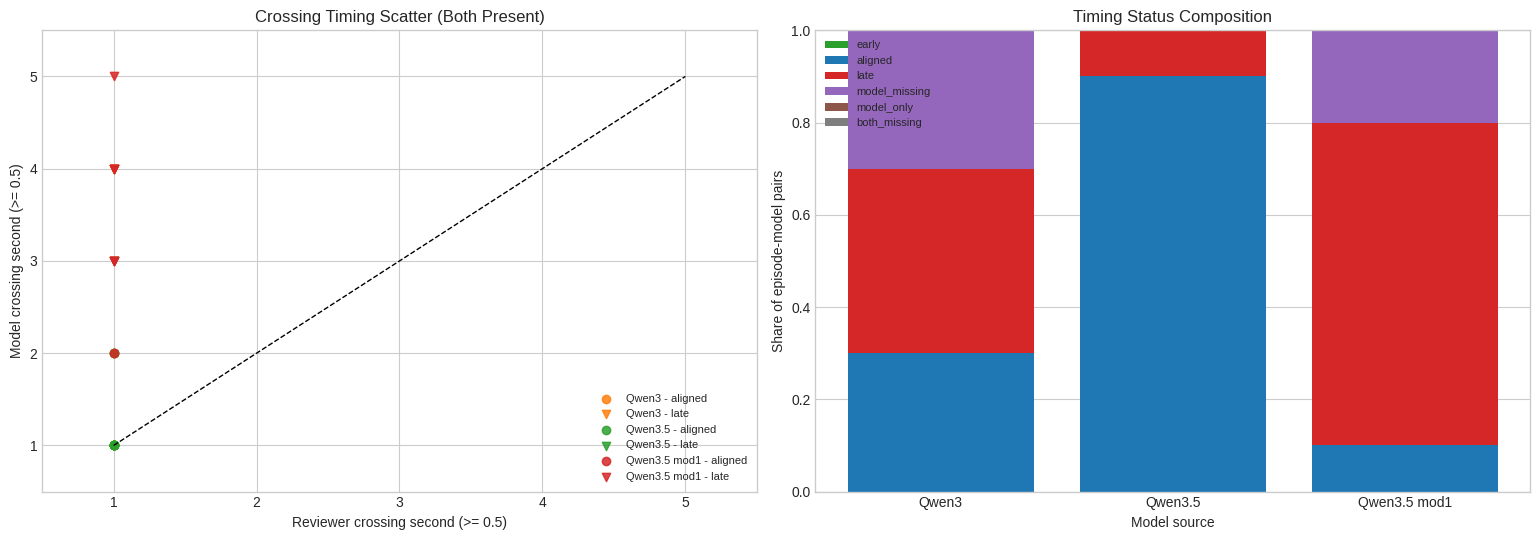

### Scenario-Level Timing Status Counts

,scenario_id,model_source,timing_status,n
0,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,Qwen3,late,1
1,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,Qwen3,model_missing,1
2,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,Qwen3.5,aligned,2
3,gr1_unified/PnPCanToDrawerClose_GR1ArmsAndWais...,Qwen3.5 mod1,late,2
4,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3,aligned,2
5,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3,late,2
6,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3.5,aligned,3
7,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3.5,late,1
8,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3.5 mod1,late,3
9,gr1_unified/PosttrainPnPNovelFromCuttingboardT...,Qwen3.5 mod1,model_missing,1


In [12]:
# Threshold crossing timing: Reviewer vs model at progress >= 0.5.
if 'PROGRESS_REVIEWED_DF' not in globals() or PROGRESS_REVIEWED_DF.empty:
    raise ValueError('Run the reviewed progress loading cell first.')

CROSS_THRESHOLD = 0.5
CROSS_ALIGN_TOL_SEC = 1
TIMING_MODELS = [m for m in ['Qwen3', 'Qwen3.5', 'Qwen3.5 mod1'] if m in PROGRESS_LONG_DF['source'].unique()]
if not TIMING_MODELS:
    raise ValueError('No model sources found for threshold crossing analysis.')

def _first_cross_second(values, seconds, threshold=0.5):
    for s, v in zip(seconds, values):
        if pd.notna(v) and float(v) >= threshold:
            return int(s)
    return np.nan

timing_rows = []
for _, row in PROGRESS_REVIEWED_DF.iterrows():
    max_valid_second = int(_episode_max_second(row, hard_cap=25))
    secs = list(range(1, max_valid_second + 1))
    if not secs:
        continue

    ep_idx = pd.to_numeric(row.get('episode_index', np.nan), errors='coerce')
    episode_key = f"{row.get('run_tag', '')}:ep_{int(ep_idx)}" if pd.notna(ep_idx) else f"{row.get('run_tag', '')}:ep_nan"
    reviewer_vals = [pd.to_numeric(row.get(f'{s}s_reviewer', np.nan), errors='coerce') for s in secs]
    reviewer_cross_second = _first_cross_second(reviewer_vals, secs, CROSS_THRESHOLD)

    for model in TIMING_MODELS:
        key_map = {'Qwen3': 'qwen3', 'Qwen3.5': 'qwen3_5', 'Qwen3.5 mod1': 'qwen3_5_mod1'}
        suffix = key_map[model]
        model_vals = [pd.to_numeric(row.get(f'{s}s_{suffix}', np.nan), errors='coerce') for s in secs]
        model_cross_second = _first_cross_second(model_vals, secs, CROSS_THRESHOLD)

        if pd.isna(reviewer_cross_second) and pd.isna(model_cross_second):
            status = 'both_missing'
            timing_delta = np.nan
        elif pd.isna(reviewer_cross_second) and pd.notna(model_cross_second):
            status = 'model_only'
            timing_delta = np.nan
        elif pd.notna(reviewer_cross_second) and pd.isna(model_cross_second):
            status = 'model_missing'
            timing_delta = np.nan
        else:
            timing_delta = int(model_cross_second - reviewer_cross_second)
            if timing_delta < -CROSS_ALIGN_TOL_SEC:
                status = 'early'
            elif timing_delta > CROSS_ALIGN_TOL_SEC:
                status = 'late'
            else:
                status = 'aligned'

        timing_rows.append({
            'scenario_id': row.get('scenario_id', ''),
            'run_tag': row.get('run_tag', ''),
            'episode_index': ep_idx,
            'episode_key': episode_key,
            'video_length_seconds': pd.to_numeric(row.get('video_length_seconds', np.nan), errors='coerce'),
            'model_source': model,
            'threshold': CROSS_THRESHOLD,
            'reviewer_cross_second': reviewer_cross_second,
            'model_cross_second': model_cross_second,
            'timing_delta_model_minus_reviewer': timing_delta,
            'timing_status': status,
        })

THRESHOLD_CROSSING_TIMING_TABLE = pd.DataFrame(timing_rows)
if THRESHOLD_CROSSING_TIMING_TABLE.empty:
    raise ValueError('No threshold crossing timing rows were generated.')

display(Markdown(f'### Threshold Crossing Timing Detail (threshold={CROSS_THRESHOLD}, tolerance=+/-{CROSS_ALIGN_TOL_SEC}s)'))
display(THRESHOLD_CROSSING_TIMING_TABLE.head(80))

# Summary by model: early/aligned/late/missing style breakdown + timing error stats for present/present rows.
status_order = ['early', 'aligned', 'late', 'model_missing', 'model_only', 'both_missing']
summary_rows = []
for model, g in THRESHOLD_CROSSING_TIMING_TABLE.groupby('model_source'):
    row_out = {'model_source': model, 'n_episode_pairs': int(len(g))}
    for st in status_order:
        n_st = int((g['timing_status'] == st).sum())
        row_out[f'n_{st}'] = n_st
        row_out[f'rate_{st}'] = n_st / len(g) if len(g) else np.nan

    gp = g[g['timing_status'].isin(['early', 'aligned', 'late'])].copy()
    row_out['n_both_present'] = int(len(gp))
    if gp.empty:
        row_out['mean_timing_delta'] = np.nan
        row_out['median_timing_delta'] = np.nan
        row_out['mae_timing_delta'] = np.nan
    else:
        deltas = pd.to_numeric(gp['timing_delta_model_minus_reviewer'], errors='coerce').dropna()
        row_out['mean_timing_delta'] = float(deltas.mean()) if not deltas.empty else np.nan
        row_out['median_timing_delta'] = float(deltas.median()) if not deltas.empty else np.nan
        row_out['mae_timing_delta'] = float(deltas.abs().mean()) if not deltas.empty else np.nan
    summary_rows.append(row_out)

THRESHOLD_CROSSING_TIMING_SUMMARY = pd.DataFrame(summary_rows).sort_values('model_source').reset_index(drop=True)
display(Markdown('### Threshold Crossing Timing Summary by Model'))
display(THRESHOLD_CROSSING_TIMING_SUMMARY)

# Plot 1: reviewer crossing second vs model crossing second (present/present only).
present = THRESHOLD_CROSSING_TIMING_TABLE[THRESHOLD_CROSSING_TIMING_TABLE['timing_status'].isin(['early', 'aligned', 'late'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5))

if present.empty:
    axes[0].text(0.5, 0.5, 'No present/present crossings to plot', ha='center', va='center')
    axes[0].axis('off')
else:
    color_map = {'Qwen3': '#ff7f0e', 'Qwen3.5': '#2ca02c', 'Qwen3.5 mod1': '#d62728'}
    marker_map = {'early': '^', 'aligned': 'o', 'late': 'v'}
    for model in sorted(present['model_source'].unique()):
        gm = present[present['model_source'].eq(model)]
        for st in ['early', 'aligned', 'late']:
            gs = gm[gm['timing_status'].eq(st)]
            if gs.empty:
                continue
            axes[0].scatter(
                gs['reviewer_cross_second'],
                gs['model_cross_second'],
                alpha=0.85,
                color=color_map.get(model, '#333333'),
                marker=marker_map[st],
                label=f"{model} - {st}",
            )
    max_sec = int(max(
        present['reviewer_cross_second'].max(skipna=True),
        present['model_cross_second'].max(skipna=True),
    ))
    axes[0].plot([1, max_sec], [1, max_sec], linestyle='--', color='black', linewidth=1)
    axes[0].set_xlim(0.5, max_sec + 0.5)
    axes[0].set_ylim(0.5, max_sec + 0.5)
    axes[0].set_xlabel('Reviewer crossing second (>= 0.5)')
    axes[0].set_ylabel('Model crossing second (>= 0.5)')
    axes[0].set_title('Crossing Timing Scatter (Both Present)')
    axes[0].legend(loc='best', fontsize=8)

# Plot 2: status composition by model.
status_counts = (
    THRESHOLD_CROSSING_TIMING_TABLE.groupby(['model_source', 'timing_status']).size()
    .rename('n').reset_index()
    .pivot(index='model_source', columns='timing_status', values='n').fillna(0)
    .reindex(columns=status_order, fill_value=0)
    .sort_index()
)
status_share = status_counts.div(status_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
status_colors = {
    'early': '#2ca02c',
    'aligned': '#1f77b4',
    'late': '#d62728',
    'model_missing': '#9467bd',
    'model_only': '#8c564b',
    'both_missing': '#7f7f7f',
}
left = np.zeros(len(status_share.index))
x = np.arange(len(status_share.index))
for st in status_order:
    vals = status_share[st].to_numpy() if st in status_share.columns else np.zeros(len(status_share.index))
    axes[1].bar(x, vals, bottom=left, color=status_colors[st], label=st)
    left = left + vals

axes[1].set_xticks(x)
axes[1].set_xticklabels(status_share.index, rotation=0)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Share of episode-model pairs')
axes[1].set_xlabel('Model source')
axes[1].set_title('Timing Status Composition')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

# Scenario-level timing summary (optional diagnostic table).
scenario_summary = (
    THRESHOLD_CROSSING_TIMING_TABLE.groupby(['scenario_id', 'model_source', 'timing_status']).size()
    .rename('n').reset_index()
)
THRESHOLD_CROSSING_SCENARIO_SUMMARY = scenario_summary
display(Markdown('### Scenario-Level Timing Status Counts'))
display(THRESHOLD_CROSSING_SCENARIO_SUMMARY.head(80))

## Direction Agreement Heatmaps Across All Valid Transitions
This section evaluates transition-level trend agreement for all valid `(t-1, t)` pairs in each episode.

Using `delta_progress_t = progress_t - progress_(t-1)` and thresholding, each transition is classified as `increasing`, `flat`, or `decreasing`.
We then compare each model to Reviewer and summarize:
1. Direction confusion heatmaps (Reviewer direction vs model direction).
2. Agreement-category heatmap by model (`same_direction`, `opposite_direction`, `flat_mismatch`).
3. Per-model agreement/disagreement rates and transition counts.

### Direction Agreement Summary (threshold = 0.05)

,model_source,n_transitions,n_same_direction,rate_same_direction,n_opposite_direction,rate_opposite_direction,n_flat_mismatch,rate_flat_mismatch
0,Qwen3,114,63,0.552632,3,0.026316,48,0.421053
1,Qwen3.5,116,71,0.612069,4,0.034483,41,0.353448
2,Qwen3.5 mod1,116,47,0.405172,14,0.120690,55,0.474138


### Reviewer vs Model Direction Confusion Heatmaps (row-normalized)

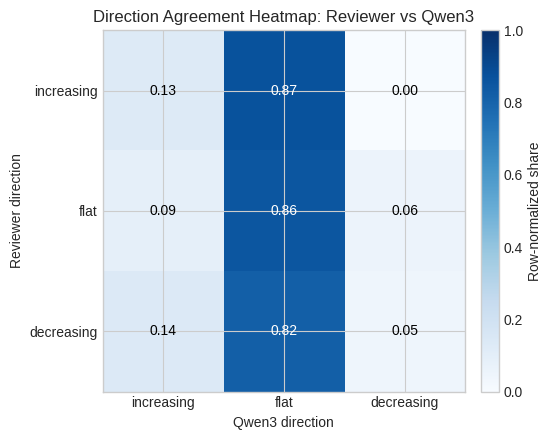

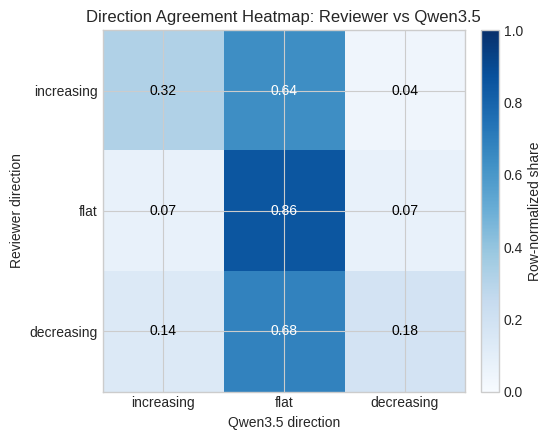

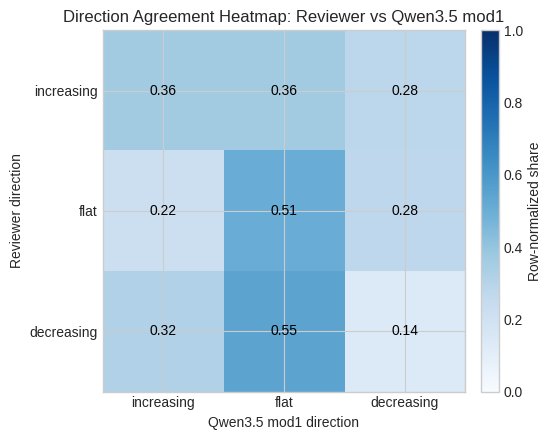

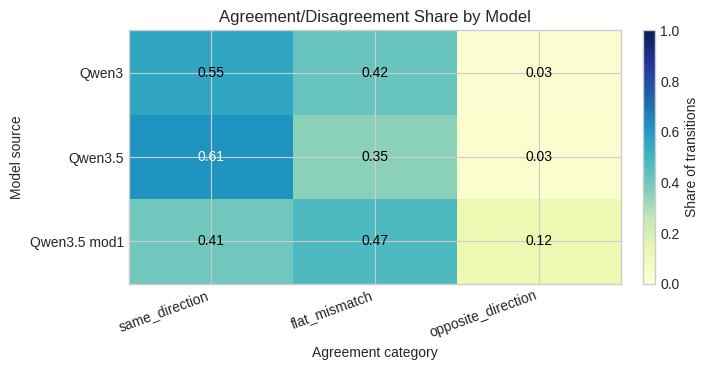

### Agreement Category Share Table

agreement_type,model_source,same_direction,flat_mismatch,opposite_direction
0,Qwen3,0.552632,0.421053,0.026316
1,Qwen3.5,0.612069,0.353448,0.034483
2,Qwen3.5 mod1,0.405172,0.474138,0.120690


In [13]:
# Transition-level direction agreement heatmaps vs Reviewer across all valid (t-1, t) pairs.
if 'PROGRESS_LONG_DF' not in globals() or PROGRESS_LONG_DF.empty:
    raise ValueError('Run the reviewed progress processing cells first to build PROGRESS_LONG_DF.')

DIR_THRESHOLD = DELTA_THRESHOLD if 'DELTA_THRESHOLD' in globals() else 0.05
DIR_MODELS = [m for m in ['Qwen3', 'Qwen3.5', 'Qwen3.5 mod1'] if m in PROGRESS_LONG_DF['source'].unique()]
if 'Reviewer' not in PROGRESS_LONG_DF['source'].unique():
    raise ValueError('Reviewer source missing from PROGRESS_LONG_DF.')
if not DIR_MODELS:
    raise ValueError('No model sources found for direction agreement analysis.')

def _direction_from_delta(d, threshold=0.05):
    if pd.isna(d):
        return np.nan
    if d > threshold:
        return 'increasing'
    if d < -threshold:
        return 'decreasing'
    return 'flat'

wide = (
    PROGRESS_LONG_DF[['episode_key', 'second', 'source', 'progress']]
    .pivot_table(index=['episode_key', 'second'], columns='source', values='progress', aggfunc='mean')
    .reset_index()
    .sort_values(['episode_key', 'second'])
)

transition_rows = []
for model in DIR_MODELS:
    pair = wide[['episode_key', 'second', 'Reviewer', model]].copy()
    pair['reviewer_delta'] = pair.groupby('episode_key')['Reviewer'].diff()
    pair['model_delta'] = pair.groupby('episode_key')[model].diff()
    pair = pair.dropna(subset=['reviewer_delta', 'model_delta']).copy()
    if pair.empty:
        continue

    pair['reviewer_direction'] = pair['reviewer_delta'].apply(lambda d: _direction_from_delta(d, DIR_THRESHOLD))
    pair['model_direction'] = pair['model_delta'].apply(lambda d: _direction_from_delta(d, DIR_THRESHOLD))

    def _agreement_type(rdir, mdir):
        if pd.isna(rdir) or pd.isna(mdir):
            return np.nan
        if rdir == mdir:
            return 'same_direction'
        if (rdir == 'flat' and mdir != 'flat') or (mdir == 'flat' and rdir != 'flat'):
            return 'flat_mismatch'
        return 'opposite_direction'

    pair['agreement_type'] = [
        _agreement_type(r, m) for r, m in zip(pair['reviewer_direction'], pair['model_direction'])
    ]
    pair['model_source'] = model
    transition_rows.append(pair[['episode_key', 'second', 'model_source', 'reviewer_delta', 'model_delta', 'reviewer_direction', 'model_direction', 'agreement_type']])

if not transition_rows:
    raise ValueError('No valid transition rows found for direction agreement heatmaps.')

DIRECTION_TRANSITION_TABLE = pd.concat(transition_rows, ignore_index=True)

# Per-model summary table for agreement/disagreement frequency.
summary_rows = []
for model, g in DIRECTION_TRANSITION_TABLE.groupby('model_source'):
    n = int(len(g))
    n_same = int((g['agreement_type'] == 'same_direction').sum())
    n_opp = int((g['agreement_type'] == 'opposite_direction').sum())
    n_flat_mis = int((g['agreement_type'] == 'flat_mismatch').sum())
    summary_rows.append({
        'model_source': model,
        'n_transitions': n,
        'n_same_direction': n_same,
        'rate_same_direction': n_same / n if n else np.nan,
        'n_opposite_direction': n_opp,
        'rate_opposite_direction': n_opp / n if n else np.nan,
        'n_flat_mismatch': n_flat_mis,
        'rate_flat_mismatch': n_flat_mis / n if n else np.nan,
    })

DIRECTION_AGREEMENT_SUMMARY = pd.DataFrame(summary_rows).sort_values('model_source').reset_index(drop=True)
display(Markdown(f'### Direction Agreement Summary (threshold = {DIR_THRESHOLD})'))
display(DIRECTION_AGREEMENT_SUMMARY)

# Heatmap set 1: reviewer->model direction confusion per model (row-normalized).
display(Markdown('### Reviewer vs Model Direction Confusion Heatmaps (row-normalized)'))
for model, g in DIRECTION_TRANSITION_TABLE.groupby('model_source'):
    conf = pd.crosstab(
        g['reviewer_direction'],
        g['model_direction'],
        normalize='index'
    ).reindex(index=['increasing', 'flat', 'decreasing'], columns=['increasing', 'flat', 'decreasing']).fillna(0.0)

    fig, ax = plt.subplots(figsize=(5.6, 4.5))
    im = ax.imshow(conf.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['increasing', 'flat', 'decreasing'])
    ax.set_yticks(range(3))
    ax.set_yticklabels(['increasing', 'flat', 'decreasing'])
    ax.set_xlabel(f'{model} direction')
    ax.set_ylabel('Reviewer direction')
    ax.set_title(f'Direction Agreement Heatmap: Reviewer vs {model}')

    vals = conf.to_numpy()
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            txt_color = 'white' if vals[i, j] >= 0.6 else 'black'
            ax.text(j, i, f"{vals[i, j]:.2f}", ha='center', va='center', color=txt_color, fontsize=10)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Row-normalized share', rotation=90)
    plt.tight_layout()
    plt.show()

# Heatmap set 2: model x agreement type share.
agreement_order = ['same_direction', 'flat_mismatch', 'opposite_direction']
agreement_share = (
    DIRECTION_TRANSITION_TABLE.groupby(['model_source', 'agreement_type']).size()
    .rename('n').reset_index()
    .pivot(index='model_source', columns='agreement_type', values='n')
    .reindex(columns=agreement_order).fillna(0)
    .sort_index()
)
agreement_share = agreement_share.div(agreement_share.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
im = ax.imshow(agreement_share.to_numpy(), cmap='YlGnBu', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(agreement_order)))
ax.set_xticklabels(agreement_order, rotation=20, ha='right')
ax.set_yticks(range(len(agreement_share.index)))
ax.set_yticklabels(list(agreement_share.index))
ax.set_xlabel('Agreement category')
ax.set_ylabel('Model source')
ax.set_title('Agreement/Disagreement Share by Model')

vals = agreement_share.to_numpy()
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        txt_color = 'white' if vals[i, j] >= 0.6 else 'black'
        ax.text(j, i, f"{vals[i, j]:.2f}", ha='center', va='center', color=txt_color, fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Share of transitions', rotation=90)
plt.tight_layout()
plt.show()

# Keep numeric table for downstream use.
DIRECTION_AGREEMENT_HEATMAP_TABLE = agreement_share.reset_index()
display(Markdown('### Agreement Category Share Table'))
display(DIRECTION_AGREEMENT_HEATMAP_TABLE)